## 미세먼지 예측(LSTM)

In [17]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 데이터 불러오기
data_path = 'dataset/seoul_pm10.csv'  # 데이터 경로
df = pd.read_csv(data_path, encoding='cp949')

# 데이터 확인
print(df.head())
#print(df.isnull().sum())
print(df.shape)
#dateList = list(df['date'].unique())
#dateList.sort()
#print(len(dateList))
#print(227760/8760) # 각 시간(8760개)마다 26개의 지역이 반복됨
df_List = df.values

df_gangnam = []
for d in df_List:
    if d[1]=='강남구':
        df_gangnam.append(d)
print(len(df_gangnam))

df_gangnam = np.array(df_gangnam)
df_gangnam = pd.DataFrame(df_gangnam)
print(df_gangnam.head())
print(df_gangnam.shape)
df_gangnam[0] = pd.to_datetime(df_gangnam[0])
df_gangnam.set_index(0, inplace=True)
df_gangnam.dropna(inplace=True)  # 결측치 제거

print(df_gangnam.head())
print(df_gangnam.shape)

df_gangnam_pm10 = df_gangnam[2].values.reshape(-1, 1)
print(df_gangnam_pm10)

               date area  pm10  pm2.5
0  2022-12-31 23:00  강남구  57.0   44.0
1  2022-12-31 23:00  강동구  68.0   55.0
2  2022-12-31 23:00  강북구  59.0   42.0
3  2022-12-31 23:00  강서구  62.0   40.0
4  2022-12-31 23:00  관악구  57.0   38.0
(227759, 4)
8760
                  0    1     2     3
0  2022-12-31 23:00  강남구  57.0  44.0
1  2022-12-31 22:00  강남구  54.0  42.0
2  2022-12-31 21:00  강남구  52.0  39.0
3  2022-12-31 20:00  강남구  51.0  38.0
4  2022-12-31 19:00  강남구  58.0  40.0
(8760, 4)
                       1     2     3
0                                   
2022-12-31 23:00:00  강남구  57.0  44.0
2022-12-31 22:00:00  강남구  54.0  42.0
2022-12-31 21:00:00  강남구  52.0  39.0
2022-12-31 20:00:00  강남구  51.0  38.0
2022-12-31 19:00:00  강남구  58.0  40.0
(8684, 3)
[[57.0]
 [54.0]
 [52.0]
 ...
 [18.0]
 [20.0]
 [18.0]]


c:\NEWTEST\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 7.1295e-04 - val_loss: 9.3726e-04
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 5.6827e-04 - val_loss: 7.5224e-04
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 4.4883e-04 - val_loss: 6.3987e-04
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 4.7923e-04 - val_loss: 5.3602e-04
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 3.1178e-04 - val_loss: 4.9650e-04
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 2.9904e-04 - val_loss: 3.8071e-04
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 2.2753e-04 - val_loss: 4.3605e-04
Epoch 9/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 2.3560e-04 - val_loss: 3.7907e-04
Epoch 10/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 2.1209e-04 - val_loss: 3.7353e-04
Epoch 11/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - l

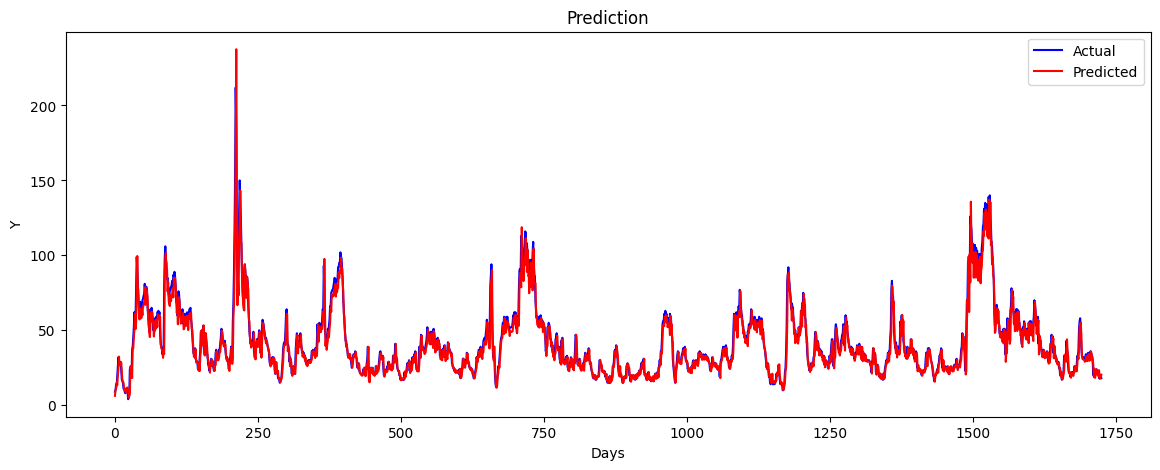

In [18]:
# 2. 데이터 전처리
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_gangnam_pm10)

def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60  # 과거 60일 데이터로 예측
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # LSTM 입력 형태

# 3. 모델 구성
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# 4. 모델 학습
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# 5. 예측 및 시각화
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))

# 실제 값 복원
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# 시각화
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label="Actual", color='blue')
plt.plot(predictions, label="Predicted", color='red')
plt.title('Prediction')
plt.xlabel('Days')
plt.ylabel('Y')
plt.legend()
plt.show()